📋 INSIGHT 4: TRANSACTIONAL INTEGRITY - LICENSE vs VALUE DISCREPANCY
✅ File found at: us_export_compliance_data_with_risk.csv

📦 Analyzing 5,000 shipments with dates from 2025-07-07 to 2026-07-06

📊 EEI THRESHOLD RESULTS:
   ┌─ Shipments exceeding $2,500 under NLR: 2,211
   ├─ Defect Rate: 44.22%
   ├─ Total Value at Risk: $1,417,623,062.12
   └─ Average Value per Violation: $641,168.28

📊 ANALYSIS BY LICENSE TYPE:


,total_shipments,eei_omission_defects,max_transaction_value,avg_transaction_value,total_value_usd,violation_rate_pct
license_type,,,,,,
NLR,2218,2211,2394468.30,639148.49,1.417631e+09,99.68
EXCEPTION,993,0,2417077.26,645011.54,6.404965e+08,0.00
LICENSE,1789,0,2445329.70,620925.52,1.110836e+09,0.00



⚠️ NLR DEFECT RATE: 99.68%
   (2,211 out of 2,218 NLR shipments exceed $2,500)
   Total value of NLR shipments: $1,417,631,343.89

📊 EEI VIOLATIONS BY BUSINESS UNIT:


,Business Unit,Total Shipments,EEI Violations,Total Value,Violation Rate %
0,US-AerospaceParts,735,332,4.713519e+08,45.17
3,US-MedicalDevices,1239,557,8.121318e+08,44.96
4,US-Pharmaceuticals,478,213,2.948135e+08,44.56
1,US-ConsumerElectronics,1582,693,9.824572e+08,43.81
2,US-IndustrialEquipment,966,416,6.082091e+08,43.06



📊 EEI VIOLATIONS BY PORT OF EXIT:


,Port of Exit,Total Shipments,EEI Violations,Total Value,Violation Rate %
3,MIAMI,715,326,4.610282e+08,45.59
1,HOUSTON,713,321,4.651421e+08,45.02
6,SEATTLE,722,325,4.691555e+08,45.01
2,LOS ANGELES,722,323,4.411995e+08,44.74
0,CHICAGO O'HARE,699,306,4.509616e+08,43.78
5,NEWARK,712,307,4.677804e+08,43.12
4,NEW YORK,717,303,4.136962e+08,42.26



📅 MONTHLY EEI VIOLATION RATE:


,Violations_Count,Total_Shipments,Violation_Rate_Pct
shipment_month,,,
2026-02,169,395,42.78
2026-03,189,402,47.01
2026-04,177,400,44.25
2026-05,188,442,42.53
2026-06,165,391,42.20
2026-07,39,93,41.94



📈 RECENT TREND (Last 6 months):
   2026-02: 42.78% █████████████████████
   2026-03: 47.01% ███████████████████████
   2026-04: 44.25% ██████████████████████
   2026-05: 42.53% █████████████████████
   2026-06: 42.20% █████████████████████
   2026-07: 41.94% ████████████████████


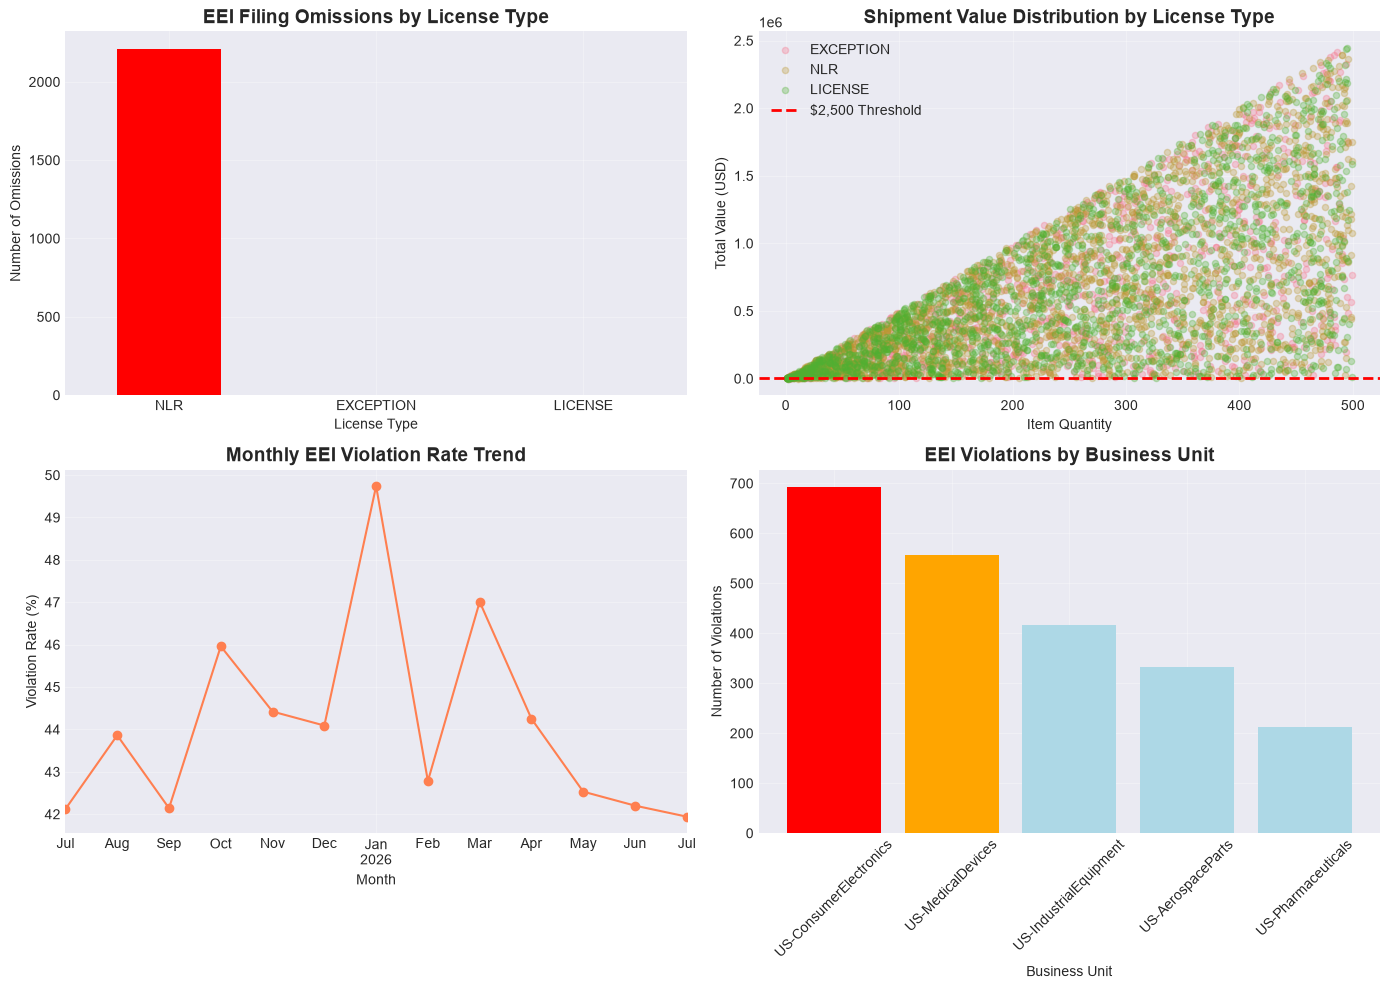


💾 Saved: output/insight4_license_integrity.png

📊 EXECUTIVE SUMMARY - LICENSE INTEGRITY

   TRANSACTIONAL INTEGRITY:
   ├─ Total EEI Violations: 2,211
   ├─ NLR Defect Rate: 99.68%
   └─ Total Value at Risk: $1,417,623,062.12

   TOP BUSINESS UNITS WITH VIOLATIONS:
   ├─ 1. US-AerospaceParts: 332 violations (45.17%)
   ├─ 2. US-MedicalDevices: 557 violations (44.96%)
   └─ 3. US-Pharmaceuticals: 213 violations (44.56%)

   RECOMMENDATIONS:
   1. Implement pre-shipment value threshold validation for all NLR shipments
   2. Auto-block shipments >$2,500 under NLR without EEI filing
   3. Review and update EEI filing procedures company-wide


✅ INSIGHT 4 COMPLETE!


In [1]:
# %% [markdown]
# # 📋 Insight 4: Transactional Integrity - License vs Value Discrepancy
# 
# **Purpose**: Identify shipments exceeding $2,500 under NLR that may be missing EEI filing
# 
# **Key Questions**:
# - What percentage of NLR shipments exceed the $2,500 threshold?
# - Which business units have the highest EEI violation rates?
# - Which ports have the most EEI filing omissions?

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("📋 INSIGHT 4: TRANSACTIONAL INTEGRITY - LICENSE vs VALUE DISCREPANCY")
print("="*70)

# %% [code]
# Load the dataset with risk flags
possible_paths = [
    '../us_export_compliance_data_with_risk.csv',
    'us_export_compliance_data_with_risk.csv',
    '../data/us_export_compliance_data_with_risk.csv',
]

df = None
for path in possible_paths:
    try:
        df = pd.read_csv(path, parse_dates=['shipment_date', 'clearance_date'])
        print(f"✅ File found at: {path}")
        break
    except FileNotFoundError:
        continue

if df is None:
    print("❌ Could not find us_export_compliance_data_with_risk.csv")
    print("Current working directory:", os.getcwd())
    print("Files in current directory:")
    print(os.listdir('.'))
    raise FileNotFoundError("CSV file not found")

print(f"\n📦 Analyzing {len(df):,} shipments with dates from {df['shipment_date'].min().strftime('%Y-%m-%d')} to {df['shipment_date'].max().strftime('%Y-%m-%d')}")

# %% [markdown]
# ## EEI Threshold Analysis

# %% [code]
# Calculate EEI threshold violations
EEI_THRESHOLD = 2500
df['eei_filing_required'] = (
    (df['total_value_usd'] > EEI_THRESHOLD) & 
    (df['license_type'] == 'NLR')
)

eei_violations = df['eei_filing_required'].sum()
eei_violation_rate = (eei_violations / len(df)) * 100
eei_total_value = df[df['eei_filing_required']]['total_value_usd'].sum()
eei_avg_value = df[df['eei_filing_required']]['total_value_usd'].mean()

print(f"\n📊 EEI THRESHOLD RESULTS:")
print(f"   ┌─ Shipments exceeding ${EEI_THRESHOLD:,} under NLR: {eei_violations:,}")
print(f"   ├─ Defect Rate: {eei_violation_rate:.2f}%")
print(f"   ├─ Total Value at Risk: ${eei_total_value:,.2f}")
print(f"   └─ Average Value per Violation: ${eei_avg_value:,.2f}")

# %% [markdown]
# ## Analysis by License Type

# %% [code]
# Group by license type
license_integrity = df.groupby('license_type').agg({
    'shipment_id': 'count',
    'eei_filing_required': 'sum',
    'total_value_usd': ['max', 'mean', 'sum']
}).round(2)

license_integrity.columns = ['total_shipments', 'eei_omission_defects', 
                             'max_transaction_value', 'avg_transaction_value', 'total_value_usd']

# Calculate violation rate
license_integrity['violation_rate_pct'] = (
    (license_integrity['eei_omission_defects'] / license_integrity['total_shipments']) * 100
).round(2)

license_integrity = license_integrity.sort_values('eei_omission_defects', ascending=False)

print("\n📊 ANALYSIS BY LICENSE TYPE:")
display(license_integrity)

# Calculate NLR defect rate
if 'NLR' in license_integrity.index:
    nlr_shipments = license_integrity.loc['NLR', 'total_shipments']
    nlr_defects = license_integrity.loc['NLR', 'eei_omission_defects']
    nlr_defect_rate = (nlr_defects / nlr_shipments * 100) if nlr_shipments > 0 else 0
    nlr_total_value = license_integrity.loc['NLR', 'total_value_usd']
    
    print(f"\n⚠️ NLR DEFECT RATE: {nlr_defect_rate:.2f}%")
    print(f"   ({nlr_defects:,} out of {nlr_shipments:,} NLR shipments exceed $2,500)")
    print(f"   Total value of NLR shipments: ${nlr_total_value:,.2f}")

# %% [markdown]
# ## Analysis by Business Unit

# %% [code]
# Group by business unit
bu_eei = df.groupby('exporter_business_unit').agg({
    'shipment_id': 'count',
    'eei_filing_required': 'sum',
    'total_value_usd': 'sum'
}).reset_index()

bu_eei.columns = ['Business Unit', 'Total Shipments', 'EEI Violations', 'Total Value']
bu_eei['Violation Rate %'] = (bu_eei['EEI Violations'] / bu_eei['Total Shipments'] * 100).round(2)
bu_eei = bu_eei.sort_values('Violation Rate %', ascending=False)

print("\n📊 EEI VIOLATIONS BY BUSINESS UNIT:")
display(bu_eei)

# %% [markdown]
# ## Analysis by Port of Exit

# %% [code]
# Group by port of exit
port_eei = df.groupby('port_of_exit').agg({
    'shipment_id': 'count',
    'eei_filing_required': 'sum',
    'total_value_usd': 'sum'
}).reset_index()

port_eei.columns = ['Port of Exit', 'Total Shipments', 'EEI Violations', 'Total Value']
port_eei['Violation Rate %'] = (port_eei['EEI Violations'] / port_eei['Total Shipments'] * 100).round(2)
port_eei = port_eei.sort_values('Violation Rate %', ascending=False)

print("\n📊 EEI VIOLATIONS BY PORT OF EXIT:")
display(port_eei)

# %% [markdown]
# ## Monthly Trend Analysis

# %% [code]
# Monthly violation rate
df['shipment_month'] = df['shipment_date'].dt.to_period('M')
monthly_eei = df.groupby('shipment_month').agg({
    'eei_filing_required': ['sum', 'count']
}).round(4)

monthly_eei.columns = ['Violations_Count', 'Total_Shipments']
monthly_eei['Violation_Rate_Pct'] = (monthly_eei['Violations_Count'] / monthly_eei['Total_Shipments'] * 100).round(2)

print("\n📅 MONTHLY EEI VIOLATION RATE:")
display(monthly_eei.tail(6))

# Show recent trend
print("\n📈 RECENT TREND (Last 6 months):")
for month, row in monthly_eei.tail(6).iterrows():
    rate = row['Violation_Rate_Pct']
    bar = '█' * int(rate / 2)
    print(f"   {month}: {rate:5.2f}% {bar}")

# %% [markdown]
# ## Visualization

# %% [code]
# Create output folder if it doesn't exist
if not os.path.exists('../output'):
    os.makedirs('../output')
    print("✅ Created output folder")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Violations by license type
violation_data = license_integrity['eei_omission_defects']
colors = ['red' if idx == 'NLR' else 'lightblue' for idx in violation_data.index]
violation_data.plot(kind='bar', ax=axes[0,0], color=colors)
axes[0,0].set_title('EEI Filing Omissions by License Type', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('License Type')
axes[0,0].set_ylabel('Number of Omissions')
axes[0,0].tick_params(axis='x', rotation=0)
axes[0,0].grid(True, alpha=0.3)

# 2. Scatter plot - value distribution by license type
for license_type in df['license_type'].unique():
    subset = df[df['license_type'] == license_type]
    axes[0,1].scatter(subset['item_quantity'], subset['total_value_usd'], 
                    alpha=0.3, label=license_type, s=20)
axes[0,1].axhline(y=2500, color='red', linestyle='--', linewidth=2, label='$2,500 Threshold')
axes[0,1].set_title('Shipment Value Distribution by License Type', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Item Quantity')
axes[0,1].set_ylabel('Total Value (USD)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Monthly violation trend
monthly_eei['Violation_Rate_Pct'].plot(kind='line', ax=axes[1,0], marker='o', color='coral')
axes[1,0].set_title('Monthly EEI Violation Rate Trend', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Violation Rate (%)')
axes[1,0].grid(True, alpha=0.3)

# 4. Violations by business unit
bu_eei_sorted = bu_eei.sort_values('EEI Violations', ascending=False)
colors_bu = ['red' if i == 0 else 'orange' if i == 1 else 'lightblue' for i in range(len(bu_eei_sorted))]
axes[1,1].bar(bu_eei_sorted['Business Unit'], bu_eei_sorted['EEI Violations'], color=colors_bu)
axes[1,1].set_title('EEI Violations by Business Unit', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Business Unit')
axes[1,1].set_ylabel('Number of Violations')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/insight4_license_integrity.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Saved: output/insight4_license_integrity.png")

# %% [markdown]
# ## Executive Summary

# %% [code]
print("\n" + "="*70)
print("📊 EXECUTIVE SUMMARY - LICENSE INTEGRITY")
print("="*70)

print(f"""
   TRANSACTIONAL INTEGRITY:
   ├─ Total EEI Violations: {eei_violations:,}
   ├─ NLR Defect Rate: {nlr_defect_rate:.2f}%
   └─ Total Value at Risk: ${eei_total_value:,.2f}

   TOP BUSINESS UNITS WITH VIOLATIONS:
   ├─ 1. {bu_eei.iloc[0]['Business Unit']}: {bu_eei.iloc[0]['EEI Violations']} violations ({bu_eei.iloc[0]['Violation Rate %']}%)
   ├─ 2. {bu_eei.iloc[1]['Business Unit']}: {bu_eei.iloc[1]['EEI Violations']} violations ({bu_eei.iloc[1]['Violation Rate %']}%)
   └─ 3. {bu_eei.iloc[2]['Business Unit']}: {bu_eei.iloc[2]['EEI Violations']} violations ({bu_eei.iloc[2]['Violation Rate %']}%)

   RECOMMENDATIONS:
   1. Implement pre-shipment value threshold validation for all NLR shipments
   2. Auto-block shipments >$2,500 under NLR without EEI filing
   3. Review and update EEI filing procedures company-wide
""")

print("\n✅ INSIGHT 4 COMPLETE!")
print("="*70)